###### 132_7_practical_daily_task_type_fill_answer.ipynb

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
plt.rcParams["font.family"] = "Meiryo"
plt.rcParams["axes.unicode_minus"] = False


In [31]:
df = pd.read_csv(
    "dataset/daily_work_minutes_practice.csv",
)
df

,work_date,task_type,work_minutes,comment
0,2022-01-01,集計,45,日次集計
1,2022-01-01,確認,30,内容確認
2,2022-01-02,資料作成,60,会議資料
3,2022-01-04,集計,90,空白あり
4,2022-01-05,確認,未入力,数値NG
5,2022-01-07,会議,120,週次会議
6,2022/01/07,議事録,40,日付表記違い
7,2022-01-09,集計,75,日次集計
8,NG_DATE,確認,30,日付NG
9,2022-01-10,資料作成,abc,数値NG


In [32]:
df["work_date_raw"] = df["work_date"]
df.head()

,work_date,task_type,work_minutes,comment,work_date_raw
0,2022-01-01,集計,45,日次集計,2022-01-01
1,2022-01-01,確認,30,内容確認,2022-01-01
2,2022-01-02,資料作成,60,会議資料,2022-01-02
3,2022-01-04,集計,90,空白あり,2022-01-04
4,2022-01-05,確認,未入力,数値NG,2022-01-05


In [33]:
df["work_date_clean"] =(
    df["work_date"]
    .astype("string")
    .str.strip()
)
df

,work_date,task_type,work_minutes,comment,work_date_raw,work_date_clean
0,2022-01-01,集計,45,日次集計,2022-01-01,2022-01-01
1,2022-01-01,確認,30,内容確認,2022-01-01,2022-01-01
2,2022-01-02,資料作成,60,会議資料,2022-01-02,2022-01-02
3,2022-01-04,集計,90,空白あり,2022-01-04,2022-01-04
4,2022-01-05,確認,未入力,数値NG,2022-01-05,2022-01-05
5,2022-01-07,会議,120,週次会議,2022-01-07,2022-01-07
6,2022/01/07,議事録,40,日付表記違い,2022/01/07,2022/01/07
7,2022-01-09,集計,75,日次集計,2022-01-09,2022-01-09
8,NG_DATE,確認,30,日付NG,NG_DATE,NG_DATE
9,2022-01-10,資料作成,abc,数値NG,2022-01-10,2022-01-10


In [34]:
df.dtypes

work_date                  object
task_type                  object
work_minutes               object
comment                    object
work_date_raw              object
work_date_clean    string[python]
dtype: object

In [35]:
df["work_date_dt"] = pd.to_datetime(
    df["work_date_clean"],
    errors="coerce",
    format="mixed",
)
df.head().dtypes

work_date                  object
task_type                  object
work_minutes               object
comment                    object
work_date_raw              object
work_date_clean    string[python]
work_date_dt       datetime64[ns]
dtype: object

In [36]:
df["task_type"]

0       集計
1       確認
2     資料作成
3       集計
4       確認
5       会議
6      議事録
7       集計
8       確認
9     資料作成
10      確認
Name: task_type, dtype: object

In [37]:
df["task_type_clean"] = (
    df["task_type"]
    .astype("string")
    .str.strip()
)
df.head()

,work_date,task_type,work_minutes,comment,work_date_raw,work_date_clean,work_date_dt,task_type_clean
0,2022-01-01,集計,45,日次集計,2022-01-01,2022-01-01,2022-01-01,集計
1,2022-01-01,確認,30,内容確認,2022-01-01,2022-01-01,2022-01-01,確認
2,2022-01-02,資料作成,60,会議資料,2022-01-02,2022-01-02,2022-01-02,資料作成
3,2022-01-04,集計,90,空白あり,2022-01-04,2022-01-04,2022-01-04,集計
4,2022-01-05,確認,未入力,数値NG,2022-01-05,2022-01-05,2022-01-05,確認


In [38]:
df["work_minutes"]

0      45
1      30
2      60
3      90
4     未入力
5     120
6      40
7      75
8      30
9     abc
10     35
Name: work_minutes, dtype: object

In [39]:
df["work_minutes_clean"] = (
    df["work_minutes"]
    .astype("string")
    .str.strip()
)
df["work_minutes_clean"]

0      45
1      30
2      60
3      90
4     未入力
5     120
6      40
7      75
8      30
9     abc
10     35
Name: work_minutes_clean, dtype: string

In [40]:
df["work_minutes_clean"]

0      45
1      30
2      60
3      90
4     未入力
5     120
6      40
7      75
8      30
9     abc
10     35
Name: work_minutes_clean, dtype: string

In [41]:
df["work_minutes_num"] = pd.to_numeric(
    df["work_minutes_clean"],
    errors="coerce",
)
df["work_minutes_num"]

0       45
1       30
2       60
3       90
4     <NA>
5      120
6       40
7       75
8       30
9     <NA>
10      35
Name: work_minutes_num, dtype: Int64

In [42]:
df["work_date_dt"]

0    2022-01-01
1    2022-01-01
2    2022-01-02
3    2022-01-04
4    2022-01-05
5    2022-01-07
6    2022-01-07
7    2022-01-09
8           NaT
9    2022-01-10
10   2022-01-10
Name: work_date_dt, dtype: datetime64[ns]

In [43]:
df_date_ng = df[
    df["work_date_dt"].isna()
].copy()
df_date_ng

,work_date,task_type,work_minutes,comment,work_date_raw,work_date_clean,work_date_dt,task_type_clean,work_minutes_clean,work_minutes_num
8,NG_DATE,確認,30,日付NG,NG_DATE,NG_DATE,NaT,確認,30,30


In [44]:
df_work = df[
    df["work_date_dt"].notna()
    & df["work_minutes_num"].notna()
    & df["task_type_clean"].notna()
].copy()

df_work

,work_date,task_type,work_minutes,comment,work_date_raw,work_date_clean,work_date_dt,task_type_clean,work_minutes_clean,work_minutes_num
0,2022-01-01,集計,45,日次集計,2022-01-01,2022-01-01,2022-01-01,集計,45,45
1,2022-01-01,確認,30,内容確認,2022-01-01,2022-01-01,2022-01-01,確認,30,30
2,2022-01-02,資料作成,60,会議資料,2022-01-02,2022-01-02,2022-01-02,資料作成,60,60
3,2022-01-04,集計,90,空白あり,2022-01-04,2022-01-04,2022-01-04,集計,90,90
5,2022-01-07,会議,120,週次会議,2022-01-07,2022-01-07,2022-01-07,会議,120,120
6,2022/01/07,議事録,40,日付表記違い,2022/01/07,2022/01/07,2022-01-07,議事録,40,40
7,2022-01-09,集計,75,日次集計,2022-01-09,2022-01-09,2022-01-09,集計,75,75
10,2022-01-10,確認,35,内容確認,2022-01-10,2022-01-10,2022-01-10,確認,35,35


In [45]:
df_work["work_date_day"] = df_work["work_date_dt"].dt.normalize()
df_work["work_date_day"]

0    2022-01-01
1    2022-01-01
2    2022-01-02
3    2022-01-04
5    2022-01-07
6    2022-01-07
7    2022-01-09
10   2022-01-10
Name: work_date_day, dtype: datetime64[ns]

In [46]:
df_work[
    [
        "work_date_day",
        "task_type_clean",
    ]
]

,work_date_day,task_type_clean
0,2022-01-01,集計
1,2022-01-01,確認
2,2022-01-02,資料作成
3,2022-01-04,集計
5,2022-01-07,会議
6,2022-01-07,議事録
7,2022-01-09,集計
10,2022-01-10,確認


In [47]:
#cell14
df_daily_task = (
    df_work
    .groupby(
        [
            "work_date_day",
            "task_type_clean",
        ]
    )
    .agg(
        work_minutes_sum=("work_minutes_num", "sum"),
        record_count=("work_minutes_num", "count"),
    )
)
df_daily_task

work_minutes_sum  record_count
work_date_day task_type_clean                                
2022-01-01    確認                             30             1
              集計                             45             1
2022-01-02    資料作成                           60             1
2022-01-04    集計                             90             1
2022-01-07    会議                            120             1
              議事録                            40             1
2022-01-09    集計                             75             1
2022-01-10    確認                             35             1

In [48]:
#cell15

date_index = pd.date_range(
    start=df_work["work_date_day"].min(),
    end=df_work["work_date_day"].max(),
    freq="D",
)
date_index

DatetimeIndex(['2022-01-01', '2022-01-02', '2022-01-03', '2022-01-04',
               '2022-01-05', '2022-01-06', '2022-01-07', '2022-01-08',
               '2022-01-09', '2022-01-10'],
              dtype='datetime64[ns]', freq='D')

In [49]:
df_work["task_type_clean"]

0       集計
1       確認
2     資料作成
3       集計
5       会議
6      議事録
7       集計
10      確認
Name: task_type_clean, dtype: string

In [50]:
#cell16 
task_types = df_work["task_type_clean"].drop_duplicates().tolist()

task_types

['集計', '確認', '資料作成', '会議', '議事録']

In [51]:
full_index = pd.MultiIndex.from_product(
    [
        date_index,
        task_types,
    ],
    names=[
        "work_date",
        "task_type",
    ],
)
full_index

MultiIndex([('2022-01-01',   '集計'),
            ('2022-01-01',   '確認'),
            ('2022-01-01', '資料作成'),
            ('2022-01-01',   '会議'),
            ('2022-01-01',  '議事録'),
            ('2022-01-02',   '集計'),
            ('2022-01-02',   '確認'),
            ('2022-01-02', '資料作成'),
            ('2022-01-02',   '会議'),
            ('2022-01-02',  '議事録'),
            ('2022-01-03',   '集計'),
            ('2022-01-03',   '確認'),
            ('2022-01-03', '資料作成'),
            ('2022-01-03',   '会議'),
            ('2022-01-03',  '議事録'),
            ('2022-01-04',   '集計'),
            ('2022-01-04',   '確認'),
            ('2022-01-04', '資料作成'),
            ('2022-01-04',   '会議'),
            ('2022-01-04',  '議事録'),
            ('2022-01-05',   '集計'),
            ('2022-01-05',   '確認'),
            ('2022-01-05', '資料作成'),
            ('2022-01-05',   '会議'),
            ('2022-01-05',  '議事録'),
            ('2022-01-06',   '集計'),
            ('2022-01-06',   '確認'),
            ('2022-01-06', '

In [54]:
filled_long = df_daily_task.reindex(
    full_index,
    fill_value=0
)
filled_long

work_minutes_sum  record_count
work_date  task_type                                
2022-01-01 集計                       45             1
           確認                       30             1
           資料作成                      0             0
           会議                        0             0
           議事録                       0             0
2022-01-02 集計                        0             0
           確認                        0             0
           資料作成                     60             1
           会議                        0             0
           議事録                       0             0
2022-01-03 集計                        0             0
           確認                        0             0
           資料作成                      0             0
           会議                        0             0
           議事録                       0             0
2022-01-04 集計                       90             1
           確認                        0             0
           資料作成                      0             0
           会議                        0             0
           議事録                       0             0
2022-01-05 集計                        0             0
           確認                        0             0
           資料作成                      0             0
           会議                        0             0
           議事録                       0             0
2022-01-06 集計                        0             0
           確認                        0             0
           資料作成                      0             0
           会議                        0             0
           議事録                       0             0
2022-01-07 集計                        0             0
           確認                        0             0
           資料作成                      0             0
           会議                      120             1
           議事録                      40             1
2022-01-08 集計                        0             0
           確認                        0             0
           資料作成                      0             0
           会議                        0             0
           議事録                       0             0
2022-01-09 集計                       75             1
           確認                        0             0
           資料作成                      0             0
           会議                        0             0
           議事録                       0             0
2022-01-10 集計                        0             0
           確認                       35             1
           資料作成                      0             0
           会議                        0             0
           議事録                       0             0

In [55]:
filled_long = filled_long.reset_index()

In [56]:
filled_long

,work_date,task_type,work_minutes_sum,record_count
0,2022-01-01,集計,45,1
1,2022-01-01,確認,30,1
2,2022-01-01,資料作成,0,0
3,2022-01-01,会議,0,0
4,2022-01-01,議事録,0,0
5,2022-01-02,集計,0,0
6,2022-01-02,確認,0,0
7,2022-01-02,資料作成,60,1
8,2022-01-02,会議,0,0
9,2022-01-02,議事録,0,0


In [57]:
matrix_df = filled_long.pivot(
    index="work_date",
    columns="task_type",
    values="work_minutes_sum",
)
matrix_df

task_type,会議,確認,議事録,資料作成,集計
work_date,,,,,
2022-01-01,0,30,0,0,45
2022-01-02,0,0,0,60,0
2022-01-03,0,0,0,0,0
2022-01-04,0,0,0,0,90
2022-01-05,0,0,0,0,0
2022-01-06,0,0,0,0,0
2022-01-07,120,0,40,0,0
2022-01-08,0,0,0,0,0
2022-01-09,0,0,0,0,75


In [58]:
matrix_df = matrix_df.fillna(0)
matrix_df

task_type,会議,確認,議事録,資料作成,集計
work_date,,,,,
2022-01-01,0,30,0,0,45
2022-01-02,0,0,0,60,0
2022-01-03,0,0,0,0,0
2022-01-04,0,0,0,0,90
2022-01-05,0,0,0,0,0
2022-01-06,0,0,0,0,0
2022-01-07,120,0,40,0,0
2022-01-08,0,0,0,0,0
2022-01-09,0,0,0,0,75


In [59]:
matrix_df.columns.name = None
matrix_df

,会議,確認,議事録,資料作成,集計
work_date,,,,,
2022-01-01,0,30,0,0,45
2022-01-02,0,0,0,60,0
2022-01-03,0,0,0,0,0
2022-01-04,0,0,0,0,90
2022-01-05,0,0,0,0,0
2022-01-06,0,0,0,0,0
2022-01-07,120,0,40,0,0
2022-01-08,0,0,0,0,0
2022-01-09,0,0,0,0,75


In [60]:
matrix_df["total_minutes"] = matrix_df[task_types].sum(axis=1)
matrix_df

,会議,確認,議事録,資料作成,集計,total_minutes
work_date,,,,,,
2022-01-01,0,30,0,0,45,75
2022-01-02,0,0,0,60,0,60
2022-01-03,0,0,0,0,0,0
2022-01-04,0,0,0,0,90,90
2022-01-05,0,0,0,0,0,0
2022-01-06,0,0,0,0,0,0
2022-01-07,120,0,40,0,0,160
2022-01-08,0,0,0,0,0,0
2022-01-09,0,0,0,0,75,75


In [61]:
task_summary = (
    filled_long
    .groupby("task_type", as_index=False)
    .agg(
        work_minutes_sum=("work_minutes_sum", "sum"),
    )
    .sort_values("work_minutes_sum", ascending=False)
)
task_summary

,task_type,work_minutes_sum
4,集計,210
0,会議,120
1,確認,65
3,資料作成,60
2,議事録,40


In [62]:
plt.figure(figsize=(8, 4))

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

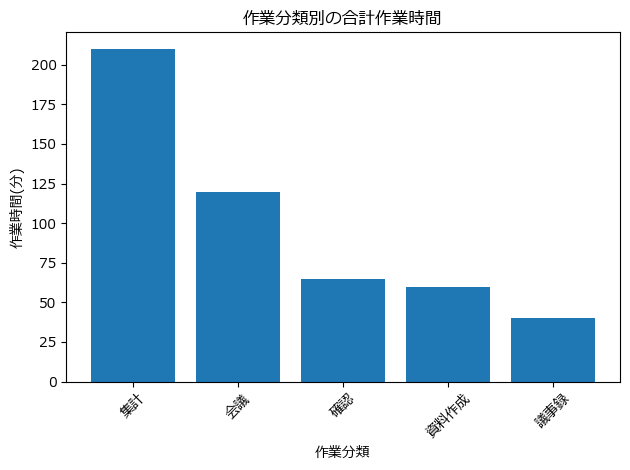

In [69]:
plt.bar(
    task_summary["task_type"],
    task_summary["work_minutes_sum"],
)

plt.title("作業分類別の合計作業時間")
plt.xlabel("作業分類")
plt.ylabel("作業時間(分)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()